In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df = pd.read_csv("../results/outputs/step5_tokenized_text.csv")

In [3]:
df.head()

,category,clean_text
0,tech,tv future hands viewers home theatre systems plasma high definition tvs digital video recorders moving living room way people watch tv radically different five years time according expert panel gathered annual consumer electronics show las vegas discuss new technologies impact one favourite pastimes us leading trend programmes content delivered viewers via home networks cable satellite telecoms companies broadband service providers front rooms portable devices one talked technologies ces digital personal video recorders dvr pvr set top boxes like us tivo uk sky system allow people record store play pause forward wind tv programmes want essentially technology allows much personalised tv also built high definition tv sets big business japan us slower take europe lack high definition programming people forward wind adverts also forget abiding network channel schedules putting together la carte entertainment us networks cable satellite companies worried means terms advertising revenues well brand identity viewer loyalty channels although us leads technology moment also concern raised europe particularly growing uptake services like sky happens today see nine months years time uk adam hume bbc broadcast futurologist told bbc news website likes bbc issues lost advertising revenue yet pressing issue moment commercial uk broadcasters brand loyalty important everyone talking content brands rather network brands said tim hanlon brand communications firm starcom mediavest reality broadband connections anybody producer content added challenge hard promote programme much choice means said stacey jolna senior vice president tv guide tv group way people find content want watch simplified tv viewers means networks us terms channels could take leaf google book search engine future instead scheduler help people find want watch kind channel model might work younger ipod generation used taking control gadgets play might suit everyone panel recognised older generations comfortable familiar schedules channel brands know getting perhaps want much choice put hands mr hanlon suggested end kids diapers pushing buttons already everything possible available said mr hanlon ultimately consumer tell market want 50 000 new gadgets technologies showcased ces many enhancing tv watching experience high definition tv sets everywhere many new models lcd liquid crystal display tvs launched dvr capability built instead external boxes one example launched show humax 26 inch lcd tv 80 hour tivo dvr dvd recorder one us biggest satellite tv companies directtv even launched branded dvr show 100 hours recording capability instant replay search function set pause rewind tv 90 hours microsoft chief bill gates announced pre show keynote speech partnership tivo called tivotogo means people play recorded programmes windows pcs mobile devices reflect increasing trend freeing multimedia people watch want want
1,business,worldcom boss left books alone former worldcom boss bernie ebbers accused overseeing 11bn 5 8bn fraud never made accounting decisions witness told jurors david myers made comments questioning defence lawyers arguing mr ebbers responsible worldcom problems phone company collapsed 2002 prosecutors claim losses hidden protect firm shares mr myers already pleaded guilty fraud assisting prosecutors monday defence lawyer reid weingarten tried distance client allegations cross examination asked mr myers ever knew mr ebbers make accounting decision aware mr myers replied ever know mr ebbers make accounting entry worldcom books mr weingarten pressed replied witness mr myers admitted ordered false accounting entries request former worldcom chief financial officer scott sullivan defence lawyers trying paint mr sullivan admitted fraud testify later trial mastermind behind worldcom accounting house cards mr ebbers team meanwhile looking portray affable boss admission pe graduate economist whatever abilities mr ebbers transformed worldcom relative 

In [4]:
df.shape

(2126, 2)

In [5]:
#apply tfidf vectorization

In [6]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_text'])
print(f"TF-IDF matrix shape: {X.shape}")

TF-IDF matrix shape: (2126, 5000)


In [7]:
#check feature names

In [8]:
feature_names = tfidf.get_feature_names_out()
print(f"Total features: {len(feature_names)}")
print("First 20:", list(feature_names[:20]))

Total features: 5000
First 20: ['000', '000m', '05', '10', '100', '100m', '10bn', '10th', '11', '110', '11bn', '12', '120', '13', '14', '15', '150', '1500m', '16', '17']


In [9]:
import matplotlib.pyplot as plt
import numpy as np

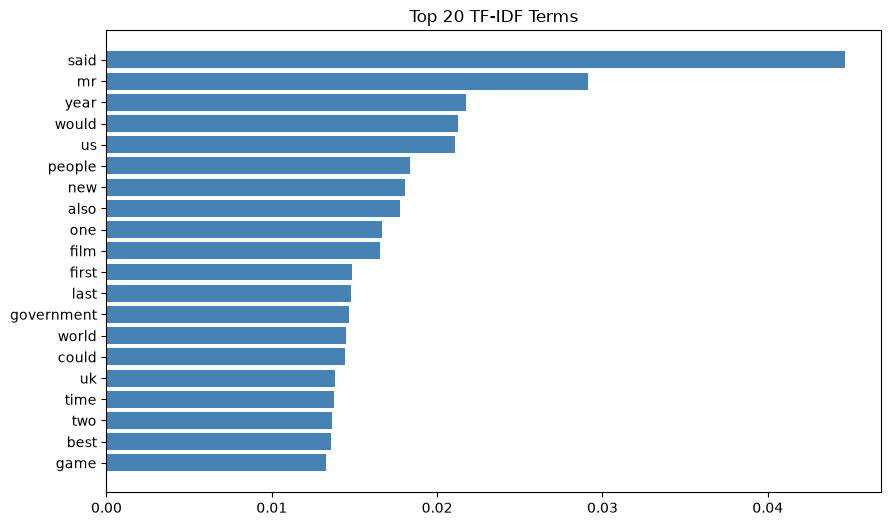

In [10]:
mean_tfidf = np.array(X.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[-20:]
top_terms = feature_names[top_idx]
top_scores = mean_tfidf[top_idx]

plt.figure(figsize=(10, 6))
plt.barh(top_terms, top_scores, color='steelblue')
plt.title('Top 20 TF-IDF Terms')
plt.show()

In [11]:
#save vectorizer

In [12]:
import joblib
joblib.dump(tfidf, '../results/model_trained_files/tfidf_vectorizer.pkl')
print("vectorizer saved")

vectorizer saved


In [13]:
#prepare train test split and save

In [14]:
from sklearn.model_selection import train_test_split

y = df['category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1700, 5000), Test: (426, 5000)


In [15]:
#save processed data
import scipy.sparse
scipy.sparse.save_npz('../results/outputs/tfidf_train.npz', X_train)
scipy.sparse.save_npz('../results/outputs/tfidf_test.npz', X_test)
y_train.to_csv('../results/outputs/train_labels.csv', index=False)
y_test.to_csv('../results/outputs/test_labels.csv', index=False)
print("all saved")

all saved
